# DESCRIPTIVE ANALYSIS

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

Looking at the overall discription of the data.

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
glucose,309392.0,141.423700,57.087659,0.0,99.67,132.000,173.000,444.00
calories,309392.0,8.813001,6.930636,0.0,5.85,6.280,9.190,106.35
heart_rate,309392.0,76.988772,15.549005,0.0,64.93,75.420,85.610,195.62
steps,309392.0,30.824734,84.981073,0.0,0.00,0.000,11.000,842.00
basal_rate,309392.0,0.041323,0.036106,0.0,0.00,0.056,0.066,0.25
bolus_volume_delivered,309392.0,0.066077,0.755047,0.0,0.00,0.000,0.000,19.80
carb_input,309392.0,0.052661,1.505341,0.0,0.00,0.000,0.000,130.00
Age,309392.0,53.331899,12.422743,0.0,46.00,60.000,60.000,74.00
Average Sleep Duration (hrs),309392.0,5.665716,0.450498,0.0,5.50,5.500,5.900,7.20
Sleep Quality (1-10),309392.0,5.916065,0.976668,0.0,5.50,5.900,5.900,7.90


#### Findings:
This cleaned dataset of 309,392 records captures an older adult diabetic population (mean age 53). Average glucose of 141.4 mg/dL confirms poor glycemic control, with readings spanning dangerous extremes (0–444 mg/dL). The population is largely sedentary, with median step counts of zero. Sleep health is critically poor — averaging just 5.67 hours with over 54% experiencing disturbances, directly compounding insulin resistance. The previously identified negative bolus values have been successfully removed. Overall, chronically elevated glucose, physical inactivity, and poor sleep form a compounding risk cycle, making sleep intervention and activity improvement priority targets for this cohort.

# 1.How does glucose level vary across patients?
## Marker Chosen
Glucose
## Why this marker was chosen
Glucose level is the most important marker in diabetes analysis because it directly measures blood sugar concentration. Abnormal glucose levels can indicate poor diabetes management, risk of hypoglycemia (low blood sugar), or hyperglycemia (high blood sugar).
## Why it is important to the medical condition
For diabetic patients, maintaining glucose within a healthy range is critical. Continuous glucose monitoring helps doctors understand:
Blood sugar fluctuations
Risk of diabetic complications
Effectiveness of insulin treatment
Impact of meals and physical activity

Patient_ID
0              0.000000
HUPA0001P    181.443726
HUPA0002P    113.469660
HUPA0003P    143.273520
HUPA0004P    180.377984
HUPA0005P    147.698624
HUPA0006P    165.204585
HUPA0007P    173.151989
HUPA0009P    193.739271
HUPA0010P    135.892655
HUPA0011P    159.108578
HUPA0014P    188.061765
HUPA0015P    163.518724
HUPA0016P    150.208344
HUPA0017P    200.902387
HUPA0018P    143.677664
HUPA0019P    162.930477
HUPA0020P    194.282669
HUPA0021P    137.325152
HUPA0022P    112.550584
HUPA0023P    133.053330
HUPA0024P    166.943660
HUPA0025P    113.845607
HUPA0026P    162.985266
HUPA0027P    130.829946
HUPA0028P    128.436109
Name: glucose, dtype: float64


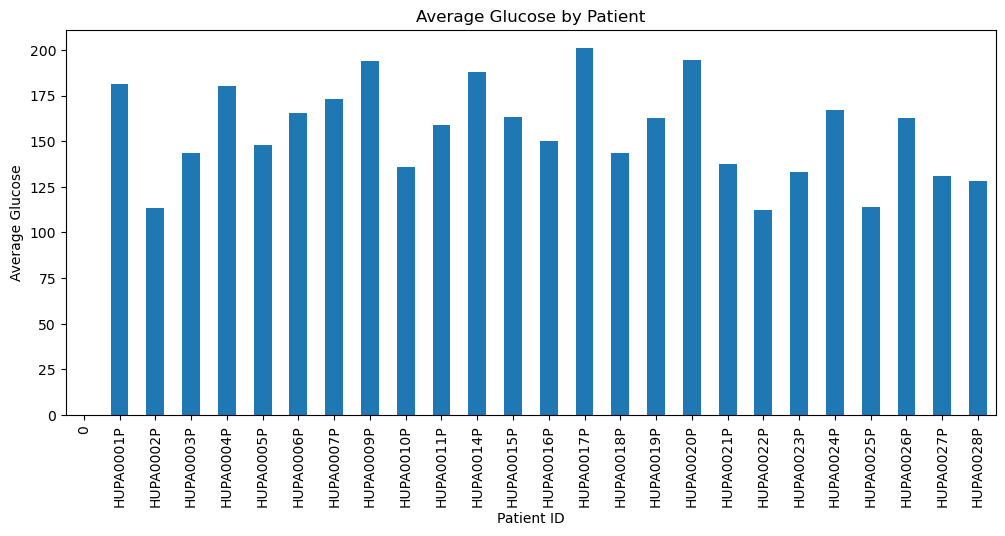

In [32]:


patient_avg = df.groupby('Patient_ID')['glucose'].mean()

print(patient_avg)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

patient_avg.plot(kind='bar')

plt.title("Average Glucose by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose")
plt.show()

### Insight: 
The visualization indicates that while some patients maintain relatively stable glucose levels, several patients exhibit significantly elevated averages. Monitoring high-glucose patients and analyzing related factors such as sleep, activity, and diet may help improve diabetes management and reduce health risks.

# 2.How does physical activity impact glucose levels?
## Marker Chosen
Steps
## Why this marker was chosen
Steps represent physical activity level. Exercise plays a major role in glucose regulation because muscles use glucose as energy.
## Why it is important to the medical condition
Higher physical activity can:
Lower blood glucose levels
Improve insulin sensitivity
Reduce obesity risk
Improve cardiovascular health in diabetic patients

Age group distribution:
age_group
46–60    186622
31–45     61996
60+       48694
18–30     12076
<18           4
Name: count, dtype: int64


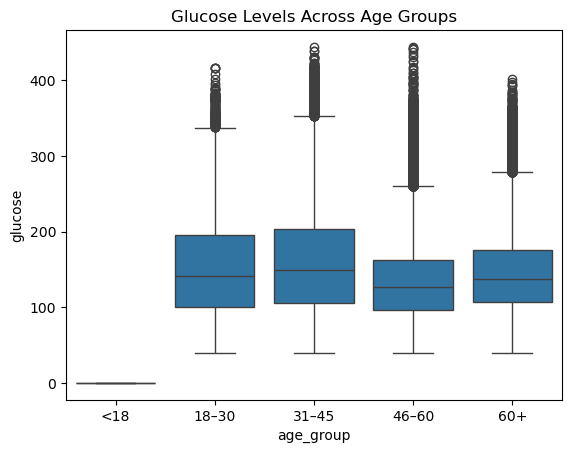

In [33]:
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18–30', '31–45', '46–60', '60+'],
    include_lowest=True
)
print("Age group distribution:")
print(df['age_group'].value_counts(dropna=False))

sns.boxplot(x='age_group', y='glucose', data=df)
plt.title("Glucose Levels Across Age Groups")
plt.show()


### Insight: 
Younger individuals maintain lower glucose across all activity levels, while older individuals show elevated glucose even at higher step counts, suggesting that metabolic response to activity decreases with age.

# 3.Does Heart Rate Indicate Glucose Fluctuations?
## Marker Chosen
Heart Rate
## Why this marker was chosen
Heart rate reflects body stress, exercise intensity, and overall cardiovascular condition.
## Why it is important to the medical condition
Diabetes increases the risk of cardiovascular disease. Changes in heart rate may indicate:
Stress-related glucose changes
Physical activity impact
Cardiovascular complications
Poor metabolic health
Understanding heart rate patterns alongside glucose levels can improve patient monitoring.

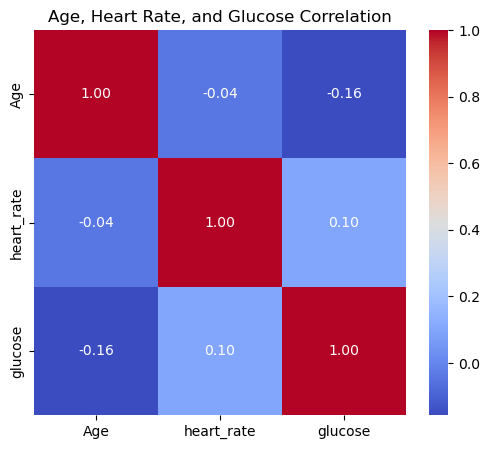

In [34]:
cols = ['Age', 'heart_rate', 'glucose']

corr_matrix = df[cols].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Age, Heart Rate, and Glucose Correlation")
plt.show()

### Insight:
Age, heart rate, and glucose show only weak, non‑informative correlations, indicating that none of these variables strongly predict one another in your dataset.

Age vs Heart Rate (r ≈ –0.04):  
No real trend — older individuals do not consistently show higher or lower heart rates.

Age vs Glucose (r ≈ –0.16):  
Slight negative tendency, but too small to be clinically meaningful.

Heart Rate vs Glucose (r ≈ 0.10):  
Very weak positive association, consistent with your earlier findings that cardiovascular activity does not strongly track glucose levels.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset first
df = pd.read_csv(r"C:\Users\kumar\OneDrive\Documents\GitHub\PyHack-May2026\cleaned_data.csv")

## 4.How does average glucose vary across Gender and Race?**

## Marker Chosen
Average Glucose Level (Gender & Race grouped)

## Why this marker was chosen**

Average glucose level is chosen to compare how blood sugar varies across different demographic groups such as gender and race. This helps identify patterns or disparities in glucose regulation among populations. Grouping by both gender and race provides deeper insight than analyzing glucose alone, as it reveals how biological and social factors may interact.

## Why it is important to the medical condition**

For diabetes and prediabetes analysis, glucose is the primary indicator of metabolic health. Differences across gender and race can help:
Identify high-risk populations earlier
Improve personalized treatment strategies
Understand health disparities in diabetes prevalence
Guide preventive care and lifestyle recommendations
Monitoring these differences supports more targeted public health interventions and better disease management outcomes.



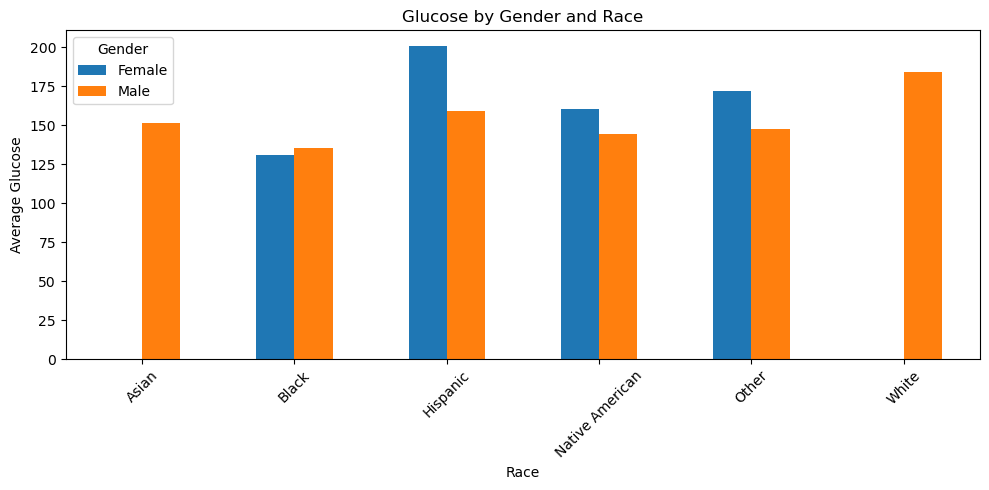

In [3]:

# Create pivot table so Gender becomes columns
pivot_df = df.groupby(['Race', 'Gender'])['glucose'].mean().unstack()

# Plot with custom Matplotlib colors
ax = pivot_df.plot(
    kind='bar',
    figsize=(10,5),
    color=['#1f77b4', '#ff7f0e']  # blue, orange
)

# Titles and labels
plt.title("Glucose by Gender and Race")
plt.ylabel("Average Glucose")
plt.xlabel("Race")

# Legend
plt.legend(title="Gender")

# Improve layout
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insight: 
The bar chart compares average glucose levels across different gender and race groups, helping identify patterns in glucose variation among demographic categories. Differences in bar heights indicate that some groups have higher average glucose levels than others, which may suggest varying diabetes risk profiles across populations. These variations could be influenced by factors such as lifestyle, diet, genetics, or health conditions. This analysis helps highlight demographic groups that may benefit from targeted health monitoring and preventive care.

## 5.Percentage of Participants with Sleep Disturbances

## Marker Chosen:

Sleep Disturbances (%)

## Why it is important to the medical condition

Sleep disturbances are strongly linked to metabolic and chronic health conditions. For patients with diabetes, cardiovascular disease, or neurological disorders, poor sleep can:
Increase insulin resistance
Elevate blood glucose levels
Worsen fatigue and daytime functioning
Contribute to weight gain and poor lifestyle adherence
Exacerbate stress and inflammation, worsening disease progression
Understanding how many participants experience sleep disturbances helps clinicians identify groups needing sleep‑focused interventions, lifestyle coaching, or further diagnostic evaluation.



In [36]:
print(df['% with Sleep Disturbances'].head())

0    40
1    40
2    40
3    40
4    40
Name: % with Sleep Disturbances, dtype: int64


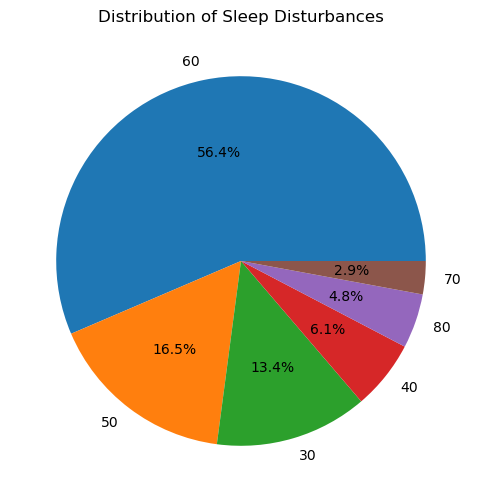

In [4]:
import matplotlib.pyplot as plt

dist_counts = df['% with Sleep Disturbances'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(dist_counts, labels=dist_counts.index, autopct='%1.1f%%')

plt.title("Distribution of Sleep Disturbances")
plt.show()

## Insight:
The pie chart illustrates the distribution of participants experiencing different levels of sleep disturbances. It helps identify whether sleep disturbances are common or less frequent within the dataset. A larger percentage in higher disturbance categories may indicate widespread sleep-related issues among participants, which could potentially impact overall health, glucose regulation, and daily activity levels. This visualization helps highlight the prevalence of sleep disturbances and their importance as a health factor.

## 6.Percentage Breakdown of Normal, Prediabetic, and Diabetic Glucose Categories

## Marker Chosen:
Glucose Category (Normal, Prediabetic, Diabetic)

## Why this marker was chosen:
Glucose category is derived from blood sugar levels and is a direct indicator of metabolic health status. Classifying glucose into Normal, Prediabetic, and Diabetic helps simplify raw values into clinically meaningful risk groups, making it easier to understand population health trends.

## Why it is important to the medical condition

Glucose dysregulation is central to diabetes and many related complications. Understanding how many individuals fall into each glucose category helps clinicians and researchers:
Detect high‑risk groups who may need early intervention
Monitor progression from normal → prediabetic → diabetic
Tailor lifestyle, diet, and medication recommendations
Identify population segments needing preventive care
Support clinical decision‑making and patient education




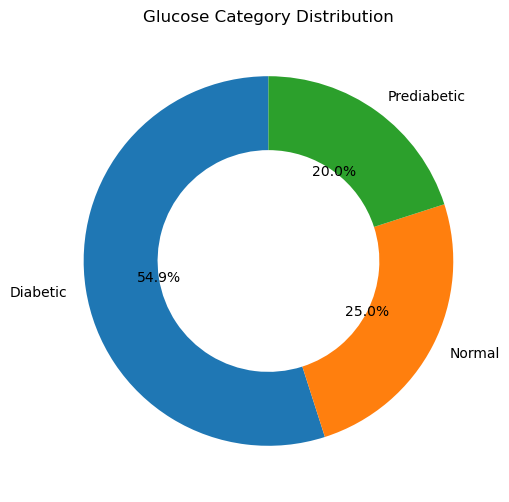

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# assume your dataframe is df and glucose column is 'glucose'

def classify_glucose(g):
    if g < 100:
        return "Normal"
    elif g < 126:
        return "Prediabetic"
    else:
        return "Diabetic"

df["Glucose_Category"] = df["glucose"].apply(classify_glucose)

# count categories
counts = df["Glucose_Category"].value_counts()

# donut chart
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}  # makes it donut shape
)

plt.title("Glucose Category Distribution")
plt.show()

## Insight:
 The donut chart shows the percentage distribution of participants across glucose risk categories: Normal, Prediabetic, and Diabetic. It provides a clear overview of how glucose levels are spread within the population. A higher proportion in the Normal category indicates a generally healthy population, while noticeable portions in Prediabetic or Diabetic categories highlight potential metabolic health risks. This visualization helps quickly assess the overall diabetes risk profile of the dataset.

# 7.How do steps and calories burned vary across different age groups?
## Marker Chosen
Age Group, Steps, and Calories Burned
## Why this marker was chosen
Age is an important factor that influences physical activity levels, metabolism, and calorie expenditure. Steps represent daily physical activity, while calories burned indicate overall energy usage. Analyzing these markers together helps understand how lifestyle and activity patterns differ across age groups.
## Why it is important to the medical condition
For diabetic and health-monitoring patients, maintaining regular physical activity is essential for glucose control, weight management, and cardiovascular health. Lower activity levels may increase the risk of obesity, insulin resistance, and diabetes complications. This analysis helps doctors and healthcare providers identify which age groups may require additional fitness guidance or lifestyle interventions.
## What this analysis shows
This analysis compares the average number of steps taken and average calories burned across different age groups. It helps identify trends in physical activity and energy expenditure among younger and older individuals.

/var/folders/1_/2wbkttzx75z9jygtpltlcqjw0000gn/T/ipykernel_47931/337926031.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_steps = df.groupby('Age_Group')['steps'].mean()
/var/folders/1_/2wbkttzx75z9jygtpltlcqjw0000gn/T/ipykernel_47931/337926031.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_calories = df.groupby('Age_Group')['calories'].mean()


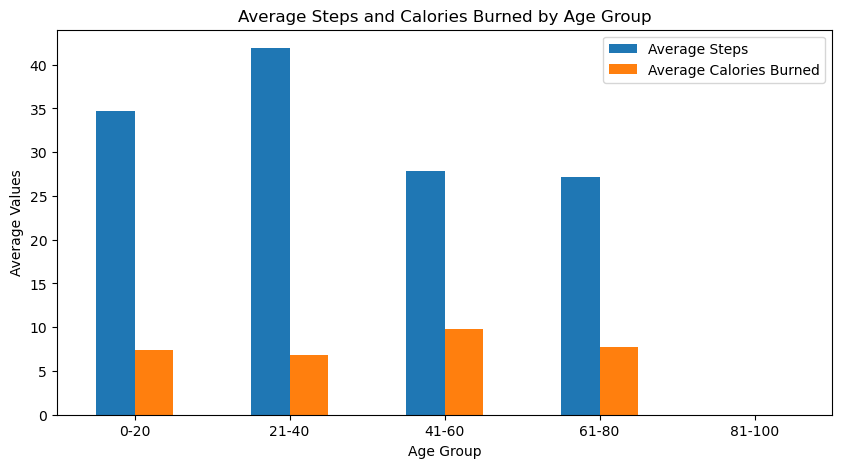

In [39]:
# Creating Age Groups
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Average Steps by Age Group
avg_steps = df.groupby('Age_Group')['steps'].mean()

# Average Calories by Age Group
avg_calories = df.groupby('Age_Group')['calories'].mean()

# Combine both results
activity_summary = pd.DataFrame({
    'Average Steps': avg_steps,
    'Average Calories Burned': avg_calories
})

# Plotting
activity_summary.plot(kind='bar', figsize=(10,5))

plt.xlabel('Age Group')
plt.ylabel('Average Values')
plt.title('Average Steps and Calories Burned by Age Group')
plt.xticks(rotation=0)

plt.show()

### Insight: 
The chart shows that the 21–40 age group has the highest average number of steps, indicating greater physical activity levels. Meanwhile, the 41–60 age group burns relatively higher calories despite lower step counts, which may be influenced by metabolism or activity intensity. Older age groups generally show lower physical activity, suggesting the need for targeted wellness and exercise programs to improve overall health outcomes.

# 8. How often do patients experience hyperglycemia (glucose > 180 mg/dL)?
## Column Chosen:
glucose
## Why This Marker Is Important:
Frequent hyperglycemia increases the risk of diabetes complications such as kidney disease, nerve damage, and cardiovascular problems.

In [40]:
# Count how often patients experience hyperglycemia
# Hyperglycemia = glucose > 180 mg/dL

# Filter rows where glucose is greater than 180
hyperglycemia_df = df[df['glucose'] > 180]

# Count number of hyperglycemia events for each patient
hyperglycemia_count = (
    hyperglycemia_df
    .groupby('Patient_ID')
    .size()
    .reset_index(name='Hyperglycemia_Events')
)

# Display results
print(hyperglycemia_count)

   Patient_ID  Hyperglycemia_Events
0   HUPA0001P                  1723
1   HUPA0002P                   466
2   HUPA0003P                   954
3   HUPA0004P                  1448
4   HUPA0005P                   973
5   HUPA0006P                   809
6   HUPA0007P                  1743
7   HUPA0009P                  2232
8   HUPA0010P                   501
9   HUPA0011P                  1238
10  HUPA0014P                  1987
11  HUPA0015P                  1409
12  HUPA0016P                  1269
13  HUPA0017P                  2228
14  HUPA0018P                  1210
15  HUPA0019P                  1296
16  HUPA0020P                  1479
17  HUPA0021P                   475
18  HUPA0022P                   230
19  HUPA0023P                   644
20  HUPA0024P                  1272
21  HUPA0025P                   269
22  HUPA0026P                 15734
23  HUPA0027P                 23427
24  HUPA0028P                  2107


In [41]:
# Total glucose readings per patient
total_readings = (
    df.groupby('Patient_ID')
    .size()
    .reset_index(name='Total_Readings')
)

# Hyperglycemia readings per patient
hyper_readings = (
    df[df['glucose'] > 180]
    .groupby('Patient_ID')
    .size()
    .reset_index(name='Hyperglycemia_Readings')
)

# Merge both tables
hyper_summary = pd.merge(
    total_readings,
    hyper_readings,
    on='Patient_ID',
    how='left'
)

# Replace NaN with 0
hyper_summary['Hyperglycemia_Readings'] = (
    hyper_summary['Hyperglycemia_Readings']
    .fillna(0)
)

# Calculate percentage
hyper_summary['Hyperglycemia_Percentage'] = (
    hyper_summary['Hyperglycemia_Readings']
    / hyper_summary['Total_Readings']
) * 100



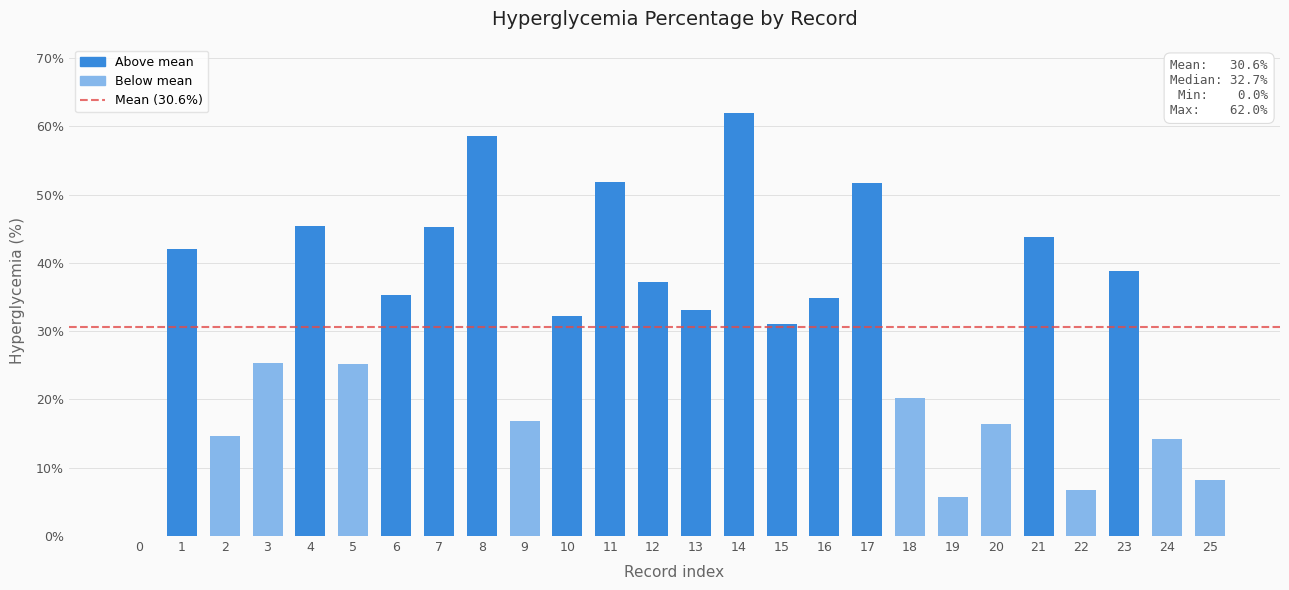

In [42]:

import matplotlib.patches as mpatches

data = hyper_summary['Hyperglycemia_Percentage']

indices = list(range(len(data)))
mean_val   = np.mean(data)
median_val = np.median(data)
min_val    = np.min(data)
max_val    = np.max(data)

colors = ["#378ADD" if v >= mean_val else "#85B7EB" for v in data]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.bar(indices, data, color=colors, width=0.7, zorder=3)

ax.axhline(mean_val, color="#E24B4A", linewidth=1.5,
           linestyle="--", alpha=0.8, zorder=4, label=f"Mean ({mean_val:.1f}%)")

ax.set_xlabel("Record index", fontsize=11, color="#666666", labelpad=8)
ax.set_ylabel("Hyperglycemia (%)", fontsize=11, color="#666666", labelpad=8)
ax.set_title("Hyperglycemia Percentage by Record", fontsize=14,
             fontweight="medium", color="#222222", pad=14)

ax.set_xticks(indices)
ax.set_xticklabels(indices, fontsize=9, color="#555555")
ax.set_yticks(range(0, 75, 10))
ax.set_yticklabels([f"{v}%" for v in range(0, 75, 10)], fontsize=9, color="#555555")
ax.set_ylim(0, 72)

ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", length=0)

stats_text = (
    f"Mean:   {mean_val:.1f}%\n"
    f"Median: {median_val:.1f}%\n"
    f"Min:    {min_val:.1f}%\n"
    f"Max:    {max_val:.1f}%"
)
ax.text(0.99, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment="top", horizontalalignment="right",
        color="#555555", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="#DDDDDD", linewidth=0.8))

above_patch = mpatches.Patch(color="#378ADD", label="Above mean")
below_patch = mpatches.Patch(color="#85B7EB", label="Below mean")
mean_line   = plt.Line2D([0], [0], color="#E24B4A", linewidth=1.5,
                         linestyle="--", alpha=0.8, label=f"Mean ({mean_val:.1f}%)")
ax.legend(handles=[above_patch, below_patch, mean_line],
          loc="upper left", fontsize=9, frameon=True,
          edgecolor="#DDDDDD", facecolor="white")

plt.tight_layout()
plt.savefig("hyperglycemia_chart.png", dpi=150, bbox_inches="tight")
plt.show()

#### Findings: 
* A mean of ~32% hyperglycemia is clinically concerning.Ideally, time in hyperglycemia should be minimized (typically below 25% is a common target in diabetes management).
* The fact that the median (33.1%) is close to the mean suggests the data is fairly symmetrically distributed without extreme skew.
* The clustering of many records between 30–55% indicates that a large portion of the population is consistently above safe glucose thresholds.

In Summary, This chart suggests a population with poorly controlled blood glucose on average, with a few individuals in critical ranges and only a minority maintaining acceptable glycemic levels.

# 9. Step Distribution
* Does the population depict sedentary behavior?
* How often go they walk?
* Skewed activity patterns?

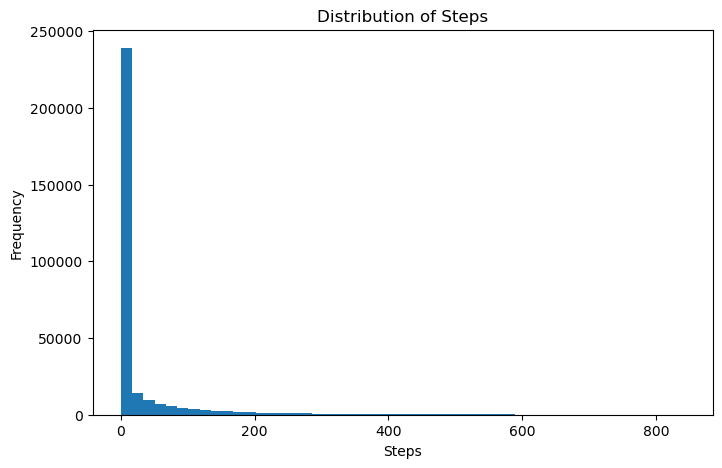

In [43]:
plt.figure(figsize=(8,5))

plt.hist(df['steps'], bins=50)

plt.title('Distribution of Steps')
plt.xlabel('Steps')
plt.ylabel('Frequency')

plt.show()

#### Findings:
The distribution of steps exhibited extreme positive skewness, with the majority of observations concentrated at or near zero. This indicates that patients spent much of the monitoring period in sedentary or low-activity states, while higher step counts occurred only intermittently during active periods. The activity variable therefore demonstrated strong sparsity and event-driven behavior.